<a href="https://colab.research.google.com/github/PrashantBagri/IP_IIIT_Delhi_2026/blob/main/18_3_ptq_pb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tempfile
import os

import tensorflow as tf
from tensorflow import keras

In [2]:
import numpy as np
import tensorflow as tf

try:
    import tf_keras as keras
except ImportError:
    from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

In [3]:
# Load MNIST
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0,1]
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Match paper setup: use 50k training samples
x_train = x_train_full[:50000]
y_train = y_train_full[:50000]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

11490434/11490434 [==============================] - 0s 0us/step
Train: (50000, 28, 28) (50000,)
Test : (10000, 28, 28) (10000,)


In [4]:
def build_float_ann():
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation="sigmoid"),
        keras.layers.Dense(10)   # logits
    ])
    return model

float_model = build_float_ann()
float_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
float_model = build_float_ann()

float_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Train model
float_history = float_model.fit(
    x_train, y_train,
    epochs=40,
    batch_size=32,
    verbose=1
)

float_test_loss, float_test_acc = float_model.evaluate(x_test, y_test, verbose=0)

print(f"FLOAT Test accuracy: {float_test_acc:.4f} | loss: {float_test_loss:.4f}")

Epoch 1/40
1563/1563 [==============================] - 10s 6ms/step - loss: 0.4367 - accuracy: 0.8868
Epoch 2/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.2170 - accuracy: 0.9378
Epoch 3/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.1612 - accuracy: 0.9533
Epoch 4/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.1269 - accuracy: 0.9632
Epoch 5/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.1024 - accuracy: 0.9711
Epoch 6/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0844 - accuracy: 0.9764
Epoch 7/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0702 - accuracy: 0.9804
Epoch 8/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.0589 - accuracy: 0.9844
Epoch 9/40
1563/1563 [==============================] - 5s 3ms/step - loss: 0.0503 - accuracy: 0.9867
Epoch 10/40
1563/1563 [==============================] - 6s 4ms/step - loss: 0.04

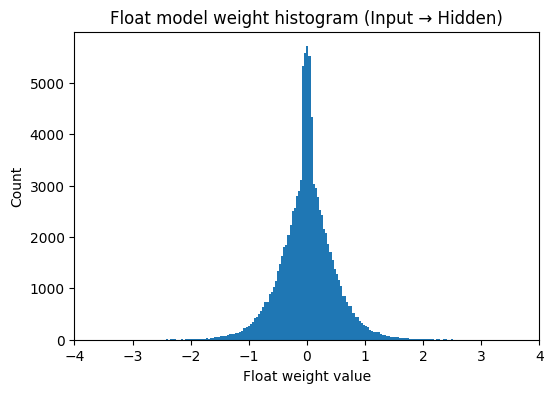

In [6]:
import matplotlib.pyplot as plt

dense_layers = [layer for layer in float_model.layers if isinstance(layer, keras.layers.Dense)]

# Only input -> hidden weights
w1 = dense_layers[0].get_weights()[0].reshape(-1)

plt.figure(figsize=(6, 4))
plt.hist(w1, bins=200)
plt.xlabel("Float weight value")
plt.ylabel("Count")
plt.title("Float model weight histogram (Input → Hidden)")
plt.xlim([-4, 4])
plt.show()

In [9]:
import numpy as np

LEVELS_NP = np.array([-1.0, -0.75, -0.25, 0.0, 0.25, 0.75, 1.0], dtype=np.float32)

print("Allowed discrete levels:", LEVELS_NP)

Allowed discrete levels: [-1.   -0.75 -0.25  0.    0.25  0.75  1.  ]


In [10]:
def hard_snap_fixed_levels(kernel, levels=LEVELS_NP):
    idx = np.argmin(np.abs(kernel[..., None] - levels), axis=-1)
    return levels[idx]

In [11]:
# Create PTQ model from trained float model
ptq_model = build_float_ann()
ptq_model.set_weights(float_model.get_weights())

ptq_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               100480    
                                                                 
 dense_5 (Dense)             (None, 10)                1290      
                                                                 
Total params: 101770 (397.54 KB)
Trainable params: 101770 (397.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
# Post-training quantization: quantize only Dense layer kernels
for layer in ptq_model.layers:
    if not isinstance(layer, keras.layers.Dense):
        continue

    weights = layer.get_weights()
    if len(weights) == 0:
        continue

    # weights[0] = kernel, weights[1] = bias
    weights[0] = hard_snap_fixed_levels(weights[0], LEVELS_NP)

    layer.set_weights(weights)

    print(f"{layer.name} unique values:")
    print(np.unique(np.round(layer.get_weights()[0], 6)))
    print()

dense_4 unique values:
[-1.   -0.75 -0.25  0.    0.25  0.75  1.  ]

dense_5 unique values:
[-1.   -0.75 -0.25  0.    0.25  0.75  1.  ]



In [13]:
ptq_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

ptq_test_loss, ptq_test_acc = ptq_model.evaluate(x_test, y_test, verbose=0)

print(f"PTQ Test accuracy: {ptq_test_acc:.4f} | loss: {ptq_test_loss:.4f}")
print(f"Accuracy drop from float model: {float_test_acc - ptq_test_acc:.4f}")

PTQ Test accuracy: 0.9489 | loss: 0.1921
Accuracy drop from float model: 0.0303


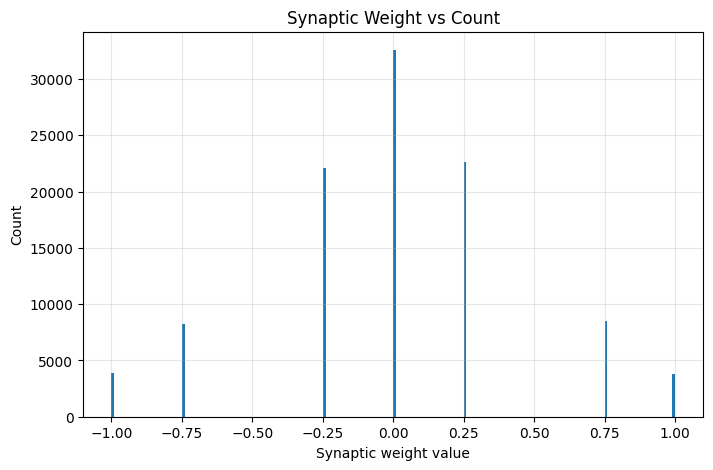

Unique weight values:
[-1.   -0.75 -0.25  0.    0.25  0.75  1.  ]


In [15]:
# Plot synaptic weight value vs count for all Dense layers in PTQ model

import numpy as np
import matplotlib.pyplot as plt

all_weights = []

for layer in ptq_model.layers:
    if not isinstance(layer, keras.layers.Dense):
        continue

    w = layer.get_weights()[0]
    all_weights.append(w.reshape(-1))

all_weights = np.concatenate(all_weights)

plt.figure(figsize=(8,5))
plt.hist(all_weights, bins=200)
plt.xlabel("Synaptic weight value")
plt.ylabel("Count")
plt.title("Synaptic Weight vs Count")
plt.grid(True, alpha=0.3)
plt.show()

print("Unique weight values:")
print(np.unique(np.round(all_weights, 6)))

In [16]:
# PTQ counter: discrete synaptic weight count

unique_vals, counts = np.unique(all_weights, return_counts=True)

print("PTQ Synaptic Weight Counter")
for val, cnt in zip(unique_vals, counts):
    print(f"{val:>6.2f} : {cnt}")

PTQ Synaptic Weight Counter
 -1.00 : 3859
 -0.75 : 8232
 -0.25 : 22134
  0.00 : 32572
  0.25 : 22591
  0.75 : 8484
  1.00 : 3760


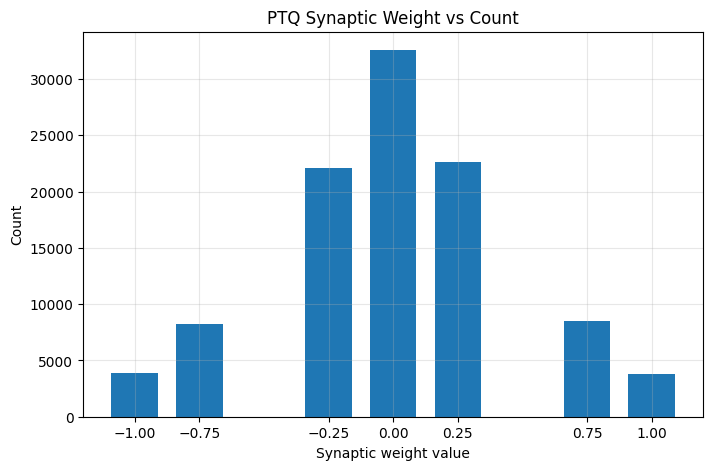

In [29]:
# Bar plot for PTQ counter

plt.figure(figsize=(8,5))
plt.bar(unique_vals, counts, width=0.18)
plt.xlabel("Synaptic weight value")
plt.ylabel("Count")
plt.title("PTQ Synaptic Weight vs Count")
plt.xticks(LEVELS_NP)
plt.grid(True, alpha=0.3)
plt.show()

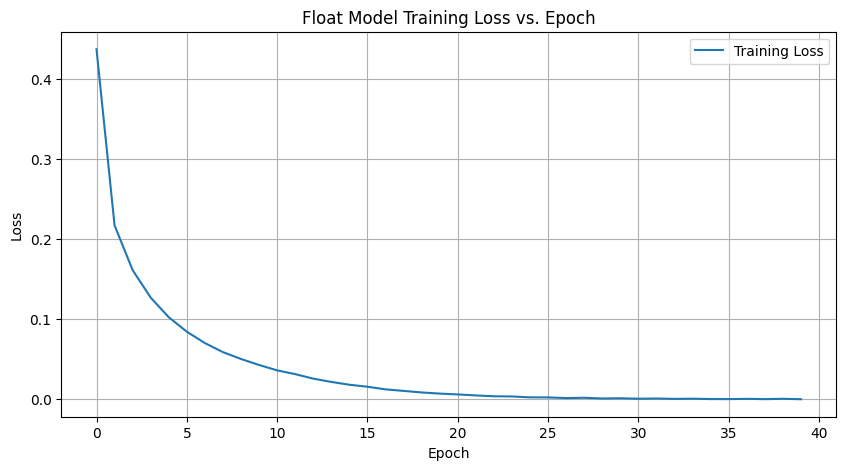

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(float_history.history['loss'], label='Training Loss')
plt.title('Float Model Training Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

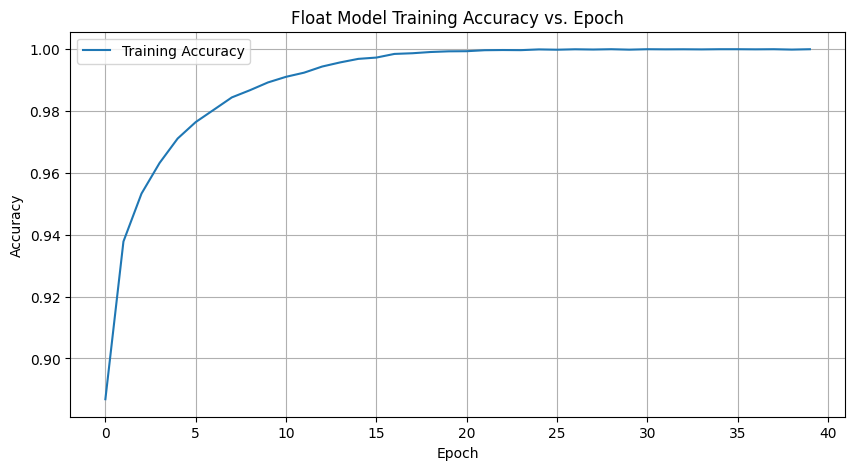

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(float_history.history['accuracy'], label='Training Accuracy')
plt.title('Float Model Training Accuracy vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
pred_float = np.argmax(model.predict(x_test[:10], verbose=0), axis=1)
pred_quant = np.argmax(quantized_model.predict(x_test[:10], verbose=0), axis=1)

print("True labels      :", y_test[:10])
print("Float predictions:", pred_float)
print("Quant predictions:", pred_quant)

True labels      : [7 2 1 0 4 1 4 9 5 9]
Float predictions: [7 2 1 0 4 1 4 9 6 9]
Quant predictions: [7 2 1 0 9 1 5 2 5 7]


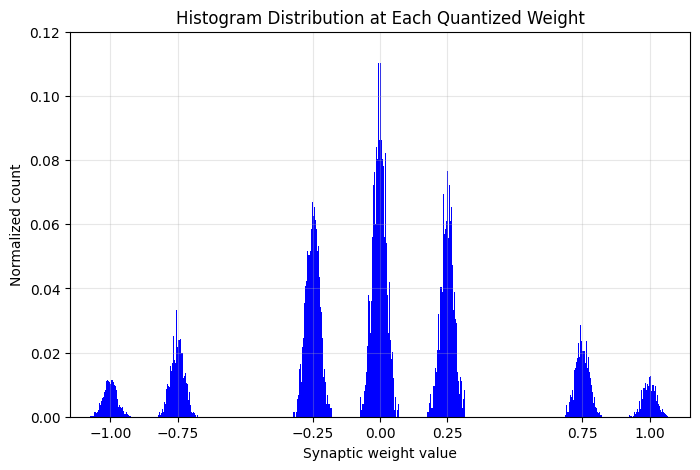

In [36]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sigma = 0.025
samples_per_peak = 4000
counts_norm = counts / np.max(counts)

for mu, h in zip(unique_vals, counts_norm):
    samples = np.random.normal(loc=mu, scale=sigma, size=samples_per_peak)
    samples = samples[(samples > mu - 3*sigma) & (samples < mu + 3*sigma)]
    weights = np.ones_like(samples) * (h / len(samples)) * 8

    plt.hist(
        samples,
        bins=200,
        weights=weights,
        # alpha=0.25,
        # edgecolor='red',
        color='blue',
        linewidth=1.2
    )

plt.xlabel("Synaptic weight value")
plt.ylabel("Normalized count")
plt.title("Histogram Distribution at Each Quantized Weight")
plt.xticks(LEVELS_NP)
plt.grid(True, alpha=0.3)
plt.xlim(min(LEVELS_NP) - 0.15, max(LEVELS_NP) + 0.15)
plt.ylim(bottom=0)
plt.show()